Exploring the dataset

In [3]:
# !pip install lightgbm pandas numpy scikit-learn matplotlib pyarrow
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score, f1_score, make_scorer
from sklearn.model_selection import train_test_split, PredefinedSplit, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV

## Load Data

In [4]:
# simplified working path (notebook runs from `notebooks/`)
data_path = Path('..') / 'dataset_candle.parquet'
data_combined_path = Path('..') / 'dataset_combined.parquet'
data_orderbook_path = Path('..') / 'dataset_orderbook.parquet'
# orderbook_features_path = Path('..') / 'data' / 'BTCUSDT' / 'processed' / 'orderbook_features.parquet'

print('reading', data_path.resolve())
print('reading', data_combined_path.resolve())
print('reading', data_orderbook_path.resolve())
# print('reading', orderbook_features_path.resolve())

data = pd.read_parquet("/content/dataset_candle.parquet")
data_combined = pd.read_parquet("/content/dataset_combined.parquet")
data_orderbook = pd.read_parquet("/content/dataset_orderbook.parquet")
# orderbook_features = pd.read_parquet(orderbook_features_path)

### Candle Data Exploration
Statistical overview, data types, distributions, and boxplot visualization of Candle features.

Shape: (40302, 18)

Columns:
Index(['open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'num_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'return', 'RSI', 'BB_upper', 'BB_lower', 'BB_width', 'ATR',
       'target'],
      dtype='object')

Head:
                         open      high       low     close    volume  \
2025-11-17 00:19:00  93942.60  93942.60  93813.00  93857.50  41.40557   
2025-11-17 00:20:00  93857.50  93904.00  93775.50  93888.31  35.55018   
2025-11-17 00:21:00  93888.32  93892.44  93806.72  93864.01  16.66150   
2025-11-17 00:22:00  93864.02  93886.79  93794.85  93828.08  20.75742   
2025-11-17 00:23:00  93828.09  93844.48  93767.27  93844.48  10.88161   

                        close_time quote_asset_volume  num_trades  \
2025-11-17 00:19:00  1763338799999   3886570.74902830        8536   
2025-11-17 00:20:00  1763338859999   3336544.60247060        7671   
2025-11-17 00:21:00  1763338919999   1563681.14430700     

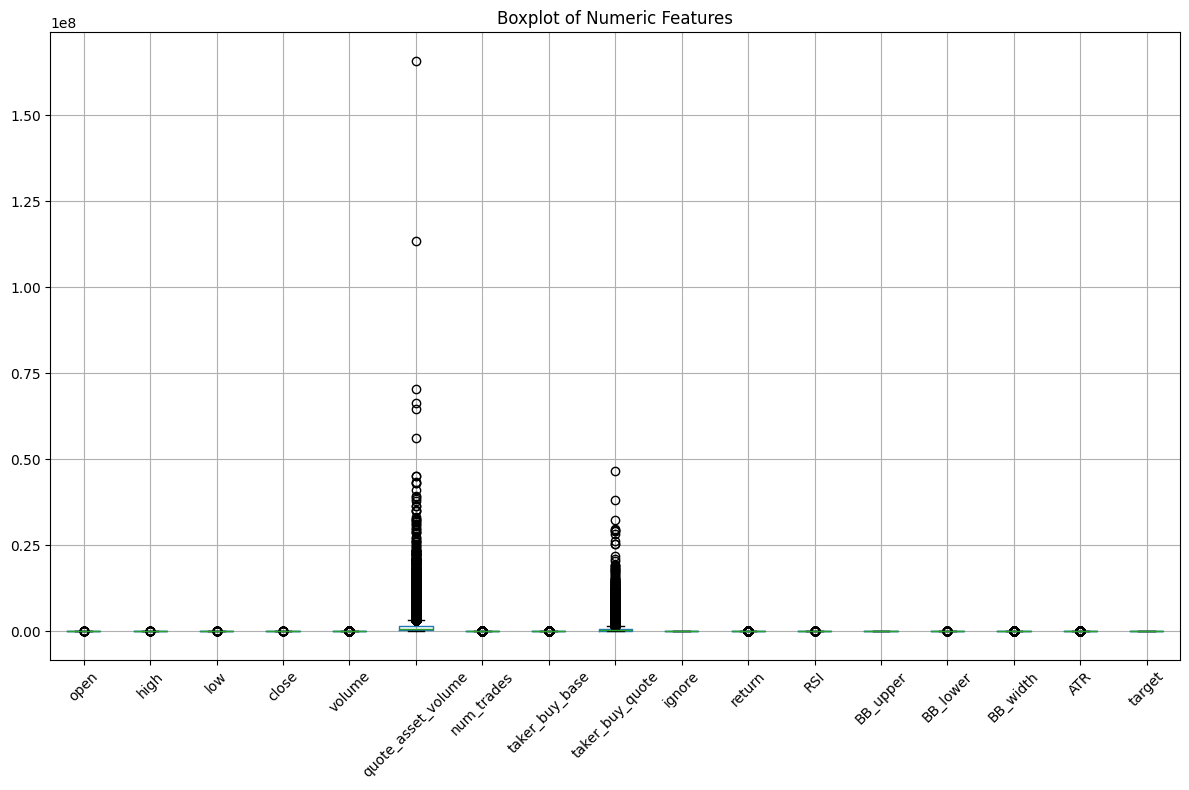

In [5]:
print("Shape:", data.shape)
print("\nColumns:")
print(data.columns)

print("\nHead:")
print(data.head())
print("\nTail:")
print(data.tail())
print("\nMissing values per column:")
print(data.isna().sum())

print("\nNumeric summary:")
print(data.describe())

print("\nCategorical summary:")
print(data.describe(include="object"))

# Change Categorical data to numeric
obj_cols = ["quote_asset_volume", "taker_buy_base", "taker_buy_quote", "ignore"]
data[obj_cols] = data[obj_cols].apply(pd.to_numeric, errors="coerce")
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Remove close_time from numeric columns for plotting
numeric_cols.remove('close_time')

print("\nInfo:")
print(data.info())
plt.figure(figsize=(12, 8))
data[numeric_cols].boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Orderbook Data Exploration
Statistical overview and distribution analysis of orderbook microstructure features.

Shape: (40302, 7)

Columns:
Index(['bid_ask_spread', 'midprice', 'bid_depth', 'ask_depth',
       'orderbook_imbalance', 'weighted_imbalance', 'target'],
      dtype='object')

Head:
                     bid_ask_spread      midprice  bid_depth  ask_depth  \
2025-11-17 00:19:00        2.545167  93828.453917   5.513737   2.978583   
2025-11-17 00:20:00        3.095333  93809.525167   4.859182   2.987165   
2025-11-17 00:21:00        3.811333  93813.219667   3.462997   3.525118   
2025-11-17 00:22:00        4.673333  93798.837667   2.661700   3.007837   
2025-11-17 00:23:00        3.618167  93773.270750   3.003775   4.235843   

                     orderbook_imbalance  weighted_imbalance  target  
2025-11-17 00:19:00             0.097007            0.088066       1  
2025-11-17 00:20:00             0.102016            0.105194      -1  
2025-11-17 00:21:00            -0.139626           -0.129366      -1  
2025-11-17 00:22:00            -0.067392           -0.077148       0  
2025-11-17 

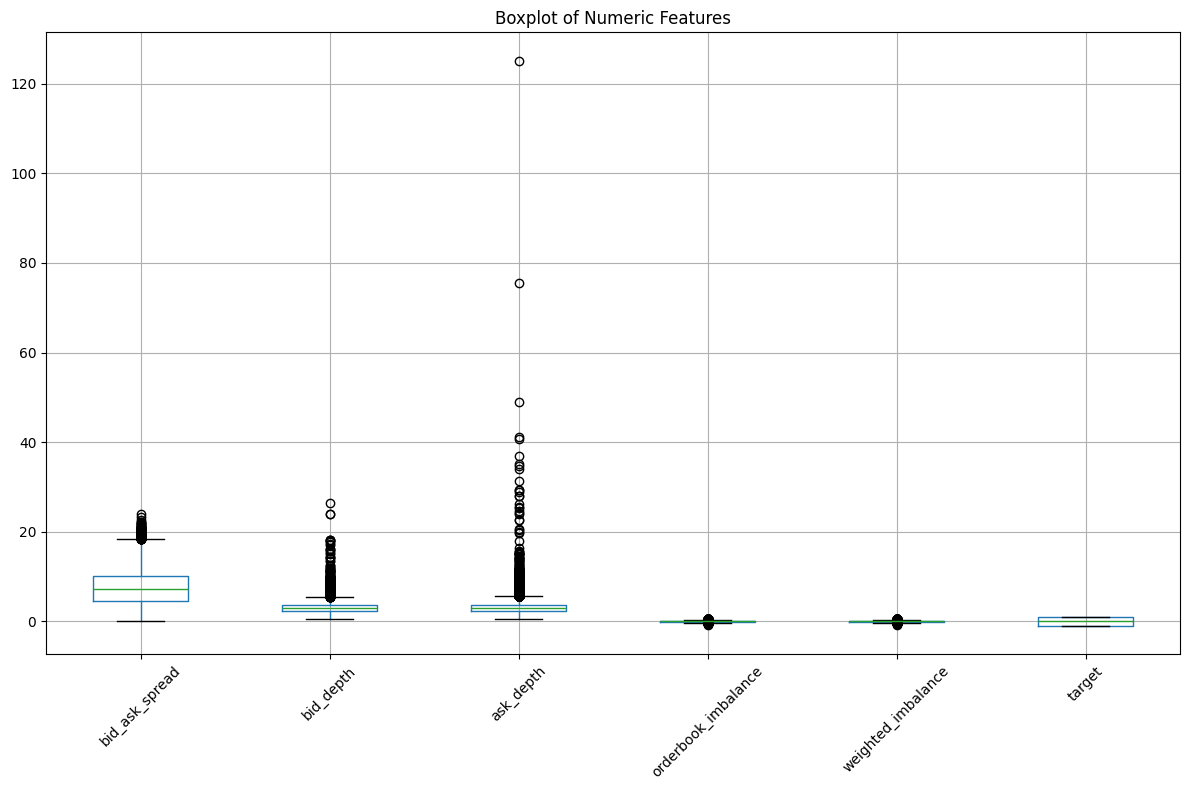

In [6]:
print("Shape:", data_orderbook.shape)
print("\nColumns:")
print(data_orderbook.columns)

print("\nHead:")
print(data_orderbook.head())

print("\nMissing values per column:")
print(data_orderbook.isna().sum())

print("\nNumeric summary:")
print(data_orderbook.describe())

numeric_cols = data_orderbook.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('midprice')  # Remove midprice from numeric columns for plotting
print("\nInfo:")
print(data_orderbook.info())
plt.figure(figsize=(12, 8))
data_orderbook[numeric_cols].boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Recalculate target value Quantile based

In [7]:
# data = data.sort_index().copy()

# H = 1  # same horizon you used before

# # 1) future return used for labeling
# fr = data["close"].shift(-H) / data["close"] - 1

# # 2) drop the last H rows (they have no future label)
# data = data.iloc[:-H].copy()
# fr = fr.iloc[:-H].copy()

# # 3) define your split points on this trimmed dataset
# gap = 5
# n = len(data)
# train_end = int(n * 0.7)
# val_end   = int(n * 0.85)

# # 4) compute quantile cutoffs on TRAIN ONLY
# q_low, q_high = 1/3, 2/3  # or try 0.30/0.70 etc
# q1 = fr.iloc[:train_end].quantile(q_low)
# q2 = fr.iloc[:train_end].quantile(q_high)

# # 5) assign quantile-based target
# target_q = np.zeros(n, dtype=int)
# target_q[fr.values <= q1] = -1
# target_q[fr.values >= q2] = 1
# data["target"] = target_q  # overwrite target

# # (optional) inspect balance
# print("Train balance:\n", pd.Series(target_q[:train_end]).value_counts(normalize=True).sort_index())
# print("All balance:\n", data["target"].value_counts(normalize=True).sort_index())


## Candle Model Pipeline
### Hyperparameter Tuning
Search for optimal XGBoost hyperparameters using candle OHLCV features with PredefinedSplit cross-validation.

In [10]:
data = data.drop(columns=["ignore", "close_time"], errors="ignore")

X = data.drop(columns=['target'])
y_raw = data['target']
y= y_raw.map({-1: 0, 0: 1, 1: 2}).astype(int)  # Map -1 to 0, 0 to 1, and 1 to 2 for multiclass classification

gap = 5  # minutes
n = len(X)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train_candle, y_train_candle = X.iloc[:train_end], y.iloc[:train_end]
X_val_candle, y_val_candle   = X.iloc[train_end+gap:val_end], y.iloc[train_end+gap:val_end]
X_test_candle, y_test_candle  = X.iloc[val_end+gap:], y.iloc[val_end+gap:]

class_counts = y_train_candle.value_counts().sort_index()
class_weights = (class_counts.sum() / class_counts).to_dict()
w_train = y_train_candle.map(class_weights).astype(float)


# # Combine train + val into one "tuning" dataset
# X_tune = np.vstack([X_train_candle.values, X_val_candle.values])
# y_tune = np.concatenate([y_train_candle.values, y_val_candle.values])

X_tune = pd.concat([X_train_candle, X_val_candle])
y_tune = pd.concat([y_train_candle, y_val_candle])


# sample weights for val too (use train-derived weights or recompute on train+val)
class_counts = y_train_candle.value_counts().sort_index()
class_weights = (class_counts.sum() / class_counts).to_dict()
w_val_candle = y_val_candle.map(class_weights).astype(float)
# w_tune_candle = np.concatenate([w_train.values, w_val_candle.values])

w_tune_candle = pd.concat([w_train, w_val_candle])

# tell sklearn: -1 means "always train", 0 means "validation fold"
test_fold = np.r_[np.full(len(X_train_candle), -1), np.zeros(len(X_val_candle))]
ps = PredefinedSplit(test_fold)

base = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=42,
    n_jobs=-1,
    metric="multi_logloss",
    verbosity=-1,  # Suppress warnings
    # device="gpu"
)

scorer = make_scorer(balanced_accuracy_score)

param_grid = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [5, 10, 20],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
    "min_split_gain": [0.0, 0.1, 0.5],
    "learning_rate": [0.02, 0.05],
    "n_estimators": [400, 800, 1200],
}

search = RandomizedSearchCV(
    base,
    param_distributions=param_grid,
    n_iter=100,
    scoring=scorer,
    cv=ps,
    n_jobs=1,
    verbose=3,
    refit=True
)

search.fit(X_tune, y_tune, sample_weight=w_tune_candle)

print("Best val score:", search.best_score_)
print("Best params:", search.best_params_)

best = search.best_estimator_
pred = best.predict(X_test_candle)

print("Balanced accuracy:", balanced_accuracy_score(y_test_candle, pred))

# Best val score: 0.4202125321590587
# Best params: {'subsample': 1.0, 'reg_lambda': 10.0, 'n_estimators': 800, 'min_split_gain': 0.5, 'min_child_weight': 20, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
# Balanced accuracy: 0.4481414114945707


Fitting 1 folds for each of 100 candidates, totalling 100 fits
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.05, max_depth=4, min_child_weight=20, min_split_gain=0.0, n_estimators=800, reg_lambda=1.0, subsample=0.7;, score=0.406 total time=  11.5s
[CV 1/1] END colsample_bytree=0.85, learning_rate=0.02, max_depth=2, min_child_weight=10, min_split_gain=0.5, n_estimators=400, reg_lambda=5.0, subsample=0.85;, score=0.412 total time=   5.0s
[CV 1/1] END colsample_bytree=0.7, learning_rate=0.02, max_depth=4, min_child_weight=20, min_split_gain=0.1, n_estimators=400, reg_lambda=10.0, subsample=0.7;, score=0.414 total time=   3.4s
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.02, max_depth=4, min_child_weight=20, min_split_gain=0.5, n_estimators=800, reg_lambda=1.0, subsample=0.85;, score=0.413 total time=  10.1s
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.02, max_depth=3, min_child_weight=5, min_split_gain=0.5, n_estimators=400, reg_lambda=5.0, subsample=0.7;, score=0.415 tot

### Train Final Candle Model with Early Stopping
Fit with early stopping on validation mlogloss, select optimal iterations, and refit on train+val data.

In [13]:
# Training final candle model with early stopping
# Using best parameters found from grid search in previous cell
parameters = search.best_params_
es = search.best_estimator_
# es = lgb.LGBMClassifier(
#     objective="multiclass",
#     num_class=3,
#     n_estimators=5000,
#     metric="multi_logloss",
#     random_state=42,
#     n_jobs=-1,
#     verbosity=-1,
#     **parameters,
# )

es.fit(
    X_train_candle, y_train_candle,
    sample_weight=w_train,
    eval_set=[(X_val_candle, y_val_candle)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
)

if 'n_estimators' in parameters:
    del parameters['n_estimators']

# Pick best iteration for initial decision weights
T = es.best_iteration_
print("Best boosting round for initial weights:", T)

# Refit final model with optimal number of trees
final_candle = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=T,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **parameters,
)

# Train on train+val for final model
X_trval = np.concatenate([X_train_candle.values, X_val_candle.values], axis=0)
y_trval = np.concatenate([y_train_candle.values, y_val_candle.values], axis=0)

final_candle.fit(X_trval, y_trval)
print("Final candle model created with", final_candle.n_estimators, "trees")

Best boosting round for initial weights: 71
Final candle model created with 71 trees


### Visualize Candle Early Stopping Curve
Plot validation mlogloss across boosting rounds with early stopping iteration marked.

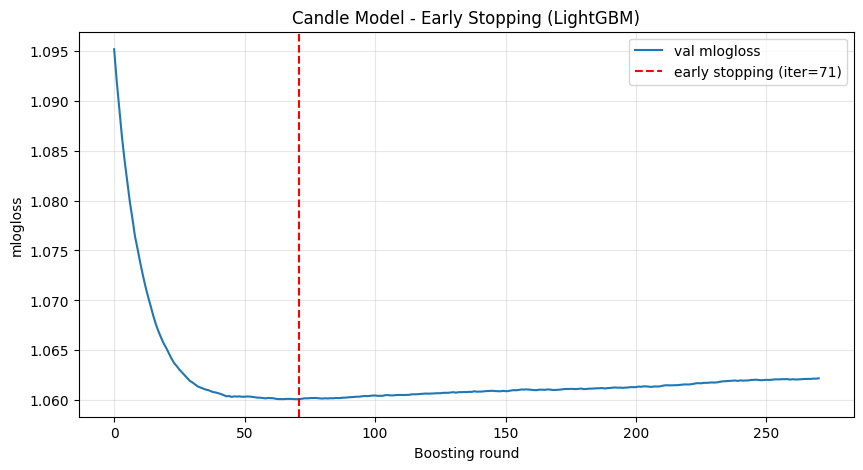

In [14]:
# Visualize early stopping on candle model
results = es.evals_result_
val_loss = np.array(results['valid_0']['multi_logloss'])
best_it = es.best_iteration_

plt.figure(figsize=(10, 5))
plt.plot(val_loss, label="val mlogloss")
plt.axvline(best_it, linestyle="--", color='red', label=f"early stopping (iter={best_it})")
plt.xlabel("Boosting round")
plt.ylabel("mlogloss")
plt.title("Candle Model - Early Stopping (LightGBM)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Candle Model Weight Optimization
Grid search for optimal class decision weights on validation set and evaluate on test set.

In [15]:
# ============================================================================
# WEIGHT OPTIMIZATION: Find optimal class weights on validation set
# ============================================================================

def predict_weighted(proba, w):
    """Apply class weights to probabilities and make predictions."""
    proba_weighted = proba * np.array(w)[None, :]
    proba_weighted = proba_weighted / proba_weighted.sum(axis=1, keepdims=True)
    return proba_weighted.argmax(axis=1)

# Grid search for optimal weights on validation data
print("Searching for optimal class weights (down, flat, up)...")
print("This may take a minute...\n")

best_w_candle, best_score_candle = None, -1

for w_down in [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 2.0, 2.5, 3.0]:
    for w_flat in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        for w_up in [1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2, 3, 4]:
            proba_val = final_candle.predict_proba(X_val_candle)
            pred = predict_weighted(proba_val, (w_down, w_flat, w_up))
            s = f1_score(y_val_candle, pred, average="macro")
            if s > best_score_candle:
                best_score_candle, best_w_candle = s, (w_down, w_flat, w_up)

print(f"✓ Candle - Best w (down, flat, up): {best_w_candle}")
print(f"  Validation F1 score: {best_score_candle:.6f}")

# Apply best weights to test set
proba_test_candle = final_candle.predict_proba(X_test_candle)
pred_test_candle_opt = predict_weighted(proba_test_candle, best_w_candle)
test_acc_candle_opt = balanced_accuracy_score(y_test_candle, pred_test_candle_opt)
print(f"  Test balanced accuracy (optimized): {test_acc_candle_opt:.6f}\n")

Searching for optimal class weights (down, flat, up)...
This may take a minute...

✓ Candle - Best w (down, flat, up): (1.2, 0.9, 1.2)
  Validation F1 score: 0.441586
  Test balanced accuracy (optimized): 0.473503



### Candle Model Evaluation
Confusion matrix, classification report, and class balance analysis for candle model.

In [16]:
print(confusion_matrix(y_test_candle, pred_test_candle_opt))
print(classification_report(y_test_candle, pred_test_candle_opt, digits=4, target_names=["down","flat","up"]))
print("training period", pd.Series(y_train_candle.value_counts(normalize=True).sort_index()))
print("test period", pd.Series(y_test_candle.value_counts(normalize=True).sort_index()))
print("validation period", pd.Series(y_val_candle.value_counts(normalize=True).sort_index()))

[[ 340  624  611]
 [ 203 2258  452]
 [ 309  577  667]]
              precision    recall  f1-score   support

        down     0.3991    0.2159    0.2802      1575
        flat     0.6528    0.7751    0.7087      2913
          up     0.3855    0.4295    0.4063      1553

    accuracy                         0.5405      6041
   macro avg     0.4791    0.4735    0.4651      6041
weighted avg     0.5179    0.5405    0.5193      6041

training period target
0    0.342526
1    0.312750
2    0.344724
Name: proportion, dtype: float64
test period target
0    0.260718
1    0.482205
2    0.257077
Name: proportion, dtype: float64
validation period target
0    0.314404
1    0.362252
2    0.323344
Name: proportion, dtype: float64


## Orderbook Model Pipeline
### Hyperparameter Tuning
Search for optimal XGBoost hyperparameters using orderbook microstructure features.

In [17]:
X = data_orderbook.drop(columns=['target'])
y_raw = data_orderbook['target']
y= y_raw.map({-1: 0, 0: 1, 1: 2}).astype(int)  # Map -1 to 0, 0 to 1, and 1 to 2 for multiclass classification

gap = 5  # minutes
n = len(X)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train_orderbook, y_train_orderbook = X.iloc[:train_end], y.iloc[:train_end]
X_val_orderbook, y_val_orderbook   = X.iloc[train_end+gap:val_end], y.iloc[train_end+gap:val_end]
X_test_orderbook, y_test_orderbook  = X.iloc[val_end+gap:], y.iloc[val_end+gap:]

class_counts = y_train_orderbook.value_counts().sort_index()
class_weights = (class_counts.sum() / class_counts).to_dict()
w_train = y_train_orderbook.map(class_weights).astype(float)


# Combine train + val into one "tuning" dataset
# X_tune_orderbook = np.vstack([X_train_orderbook.values, X_val_orderbook.values])
# y_tune_orderbook = np.concatenate([y_train_orderbook.values, y_val_orderbook.values])

X_tune_orderbook = pd.concat([X_train_orderbook, X_val_orderbook])
y_tune_orderbook = pd.concat([y_train_orderbook, y_val_orderbook])

# sample weights for val too (use train-derived weights or recompute on train+val)
class_counts = y_train_orderbook.value_counts().sort_index()
class_weights = (class_counts.sum() / class_counts).to_dict()
w_val_orderbook = y_val_orderbook.map(class_weights).astype(float)
# w_tune_orderbook = np.concatenate([w_train.values, w_val_orderbook.values])

w_tune_orderbook = pd.concat([w_train, w_val_orderbook])

# tell sklearn: -1 means "always train", 0 means "validation fold"
test_fold = np.r_[np.full(len(X_train_orderbook), -1), np.zeros(len(X_val_orderbook))]
ps = PredefinedSplit(test_fold)

base = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=42,
    n_jobs=-1,
    metric="multi_logloss",
    n_estimators=800,
    verbosity=-1
)

scorer = make_scorer(balanced_accuracy_score)

param_grid = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [5, 10, 20],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
    "min_split_gain": [0.0, 0.1, 0.2],
    "learning_rate": [0.02, 0.05],
}

search = RandomizedSearchCV(
    base,
    param_distributions=param_grid,
    n_iter=100,
    scoring=scorer,
    cv=ps,
    n_jobs=1,
    verbose=3,
    refit=True
)

search.fit(X_tune, y_tune, sample_weight=w_tune_candle)

print("Best val score:", search.best_score_)
print("Best params:", search.best_params_)

best = search.best_estimator_
pred = best.predict(X_test_candle)

print("Balanced accuracy:", balanced_accuracy_score(y_test_candle, pred))

# grid = GridSearchCV(
#     base, param_grid=param_grid, scoring=scorer, cv=ps,
#     n_jobs=-1, verbose=2, refit=True
# )

# grid.fit(X_tune_orderbook, y_tune_orderbook, sample_weight=w_tune_orderbook)

# print("Best val score:", grid.best_score_)
# print("Best params:", grid.best_params_)

# best = grid.best_estimator_
# pred = best.predict(X_test_orderbook)

# print("Balanced accuracy:", balanced_accuracy_score(y_test_orderbook, pred))

# Best val score: 0.41835341012832616
# Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'min_split_gain': 0.0, 'min_child_weight': 20, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.85}
# Balanced accuracy: 0.4512942324553617

Fitting 1 folds for each of 100 candidates, totalling 100 fits
[CV 1/1] END colsample_bytree=0.85, learning_rate=0.02, max_depth=4, min_child_weight=5, min_split_gain=0.0, reg_lambda=5.0, subsample=1.0;, score=0.416 total time=   9.8s
[CV 1/1] END colsample_bytree=0.85, learning_rate=0.05, max_depth=4, min_child_weight=5, min_split_gain=0.1, reg_lambda=1.0, subsample=0.7;, score=0.408 total time=   9.9s
[CV 1/1] END colsample_bytree=0.7, learning_rate=0.05, max_depth=2, min_child_weight=10, min_split_gain=0.1, reg_lambda=1.0, subsample=0.85;, score=0.408 total time=   4.8s
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.02, max_depth=3, min_child_weight=10, min_split_gain=0.0, reg_lambda=1.0, subsample=0.7;, score=0.415 total time=   8.8s
[CV 1/1] END colsample_bytree=0.85, learning_rate=0.02, max_depth=2, min_child_weight=5, min_split_gain=0.1, reg_lambda=1.0, subsample=0.7;, score=0.411 total time=   5.2s
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.02, max_depth=4, min_chil

### Train Final Orderbook Model with Early Stopping
Fit with early stopping on validation mlogloss, select optimal iterations, and refit on train+val data.

In [18]:
parameters = search.best_params_
es = search.best_estimator_
# 1) Fit with early stopping on a smooth metric
# es = lgb.LGBMClassifier(
#     objective="multiclass",
#     num_class=3,
#     n_estimators=5000,
#     metric="multi_logloss",
#     random_state=42,
#     n_jobs=-1,
#     verbosity=-1,
#     **parameters,
# )

es.fit(
    X_train_orderbook, y_train_orderbook,
    sample_weight=w_train,
    eval_set=[(X_val_orderbook, y_val_orderbook)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
)

# 2) Pick best iteration for *your* metric (weighted decision rule)
T = es.best_iteration_
print("Best boosting round for weighted balanced acc:", T)

if 'n_estimators' in parameters:
    del parameters['n_estimators']

# 3) Refit final model (no early stopping), using that number of trees
final_orderbook = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=T,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **parameters,
)

# optional: train on train+val now that best_t is chosen
X_trval = np.concatenate([X_train_orderbook.values, X_val_orderbook.values], axis=0)
y_trval = np.concatenate([y_train_orderbook.values, y_val_orderbook.values], axis=0)

final_orderbook.fit(X_trval, y_trval)

# test with the same decision rule
proba_test = final_orderbook.predict_proba(X_test_orderbook)
pred_test = (proba_test).argmax(axis=1)
# test with the same decision rule
print("Final candle model created with", final_orderbook.n_estimators, "trees")
print("Test weighted balanced acc:", balanced_accuracy_score(y_test_orderbook, pred_test))

Best boosting round for weighted balanced acc: 103
Final candle model created with 103 trees
Test weighted balanced acc: 0.43884955214137694


### Orderbook Model Weight Optimization
Grid search for optimal class decision weights on validation set and evaluate on test set.

In [19]:
# ============================================================================
# WEIGHT OPTIMIZATION: Find optimal class weights on validation set
# ============================================================================

def predict_weighted(proba, w):
    """Apply class weights to probabilities and make predictions."""
    proba_weighted = proba * np.array(w)[None, :]
    proba_weighted = proba_weighted / proba_weighted.sum(axis=1, keepdims=True)
    return proba_weighted.argmax(axis=1)

# Grid search for optimal weights on validation data
print("Searching for optimal class weights (down, flat, up)...")
print("This may take a minute...\n")

best_w_orderbook, best_score_orderbook = None, -1

for w_down in [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 2.0, 2.5, 3.0]:
    for w_flat in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        for w_up in [1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2, 3, 4]:
            proba_val = final_orderbook.predict_proba(X_val_orderbook)
            pred = predict_weighted(proba_val, (w_down, w_flat, w_up))
            s = f1_score(y_val_orderbook, pred, average="macro")
            if s > best_score_orderbook:
                best_score_orderbook, best_w_orderbook = s, (w_down, w_flat, w_up)

print(f"✓ Orderbook - Best w (down, flat, up): {best_w_orderbook}")
print(f"  Validation F1 score: {best_score_orderbook:.6f}")

# Apply best weights to test set
proba_test_orderbook = final_orderbook.predict_proba(X_test_orderbook)
pred_test_orderbook_opt = predict_weighted(proba_test_orderbook, best_w_orderbook)
test_acc_orderbook_opt = balanced_accuracy_score(y_test_orderbook, pred_test_orderbook_opt)
print(f"  Test balanced accuracy (optimized): {test_acc_orderbook_opt:.6f}\n")

Searching for optimal class weights (down, flat, up)...
This may take a minute...

✓ Orderbook - Best w (down, flat, up): (1.3, 1.0, 1.3)
  Validation F1 score: 0.427339
  Test balanced accuracy (optimized): 0.449410



### Orderbook Model Evaluation
Confusion matrix, classification report, and class balance analysis for orderbook model.

In [20]:
print(confusion_matrix(y_test_orderbook, pred_test_orderbook_opt))
print(classification_report(y_test_orderbook, pred_test_orderbook_opt, digits=4, target_names=["down","flat","up"]))
print("training period", pd.Series(y_train_orderbook.value_counts(normalize=True).sort_index()))
print("test period", pd.Series(y_test_orderbook.value_counts(normalize=True).sort_index()))
print("validation period", pd.Series(y_val_orderbook.value_counts(normalize=True).sort_index()))

[[ 584  442  549]
 [ 515 1825  573]
 [ 622  386  545]]
              precision    recall  f1-score   support

        down     0.3393    0.3708    0.3544      1575
        flat     0.6879    0.6265    0.6558      2913
          up     0.3269    0.3509    0.3385      1553

    accuracy                         0.4890      6041
   macro avg     0.4514    0.4494    0.4495      6041
weighted avg     0.5042    0.4890    0.4956      6041

training period target
0    0.342526
1    0.312750
2    0.344724
Name: proportion, dtype: float64
test period target
0    0.260718
1    0.482205
2    0.257077
Name: proportion, dtype: float64
validation period target
0    0.314404
1    0.362252
2    0.323344
Name: proportion, dtype: float64


## Ensemble: Candle + Orderbook Blending
Find optimal alpha weight to blend candle and orderbook model probabilities for combined predictions.

## Combined Model Pipeline
### Combined Data Exploration
Statistical overview and distribution analysis of combined candle + orderbook features.

In [21]:
assert X_val_candle.index.equals(X_val_orderbook.index)
assert X_test_candle.index.equals(X_test_orderbook.index)
assert y_val_candle.index.equals(y_val_orderbook.index)
assert y_test_candle.index.equals(y_test_orderbook.index)

def weight_probs(proba, w):
    w = np.array(w)
    proba_w = proba * w[None, :]
    proba_w = proba_w / proba_w.sum(axis=1, keepdims=True)
    return proba_w

# Get validation probabilities and apply optimized decision weights per model
p_val_c = weight_probs(final_candle.predict_proba(X_val_candle), best_w_candle)
p_val_o = weight_probs(final_orderbook.predict_proba(X_val_orderbook), best_w_orderbook)

best_alpha, best_score = None, -1

for alpha in np.linspace(0, 1, 21):  # 0.00 ... 1.00
    p_mix = alpha * p_val_c + (1 - alpha) * p_val_o
    pred = p_mix.argmax(axis=1)
    score = balanced_accuracy_score(y_val_candle, pred)
    if score > best_score:
        best_score, best_alpha = score, alpha

# Compute test score using the same weighted decision rules
p_test_c = weight_probs(final_candle.predict_proba(X_test_candle), best_w_candle)
p_test_o = weight_probs(final_orderbook.predict_proba(X_test_orderbook), best_w_orderbook)
p_test_mix = best_alpha * p_test_c + (1 - best_alpha) * p_test_o
pred_test = p_test_mix.argmax(axis=1)
test_score = balanced_accuracy_score(y_test_candle, pred_test)

print(f"Best alpha: {best_alpha}  Val balanced acc: {best_score:.6f}  Test balanced acc: {test_score:.6f}")


Best alpha: 0.5  Val balanced acc: 0.455472  Test balanced acc: 0.473012


Creating a model with the combined data set of orderbook and candle based data. First exploring combined data,

### Identify Tail-Heavy Features
Analyze feature distributions using p99/p50 ratio to identify candidates for log transformation.

Shape: (40302, 24)

Columns:
Index(['open', 'high', 'low', 'close', 'volume', 'close_time',
       'quote_asset_volume', 'num_trades', 'taker_buy_base', 'taker_buy_quote',
       'ignore', 'return', 'RSI', 'BB_upper', 'BB_lower', 'BB_width', 'ATR',
       'bid_ask_spread', 'midprice', 'bid_depth', 'ask_depth',
       'orderbook_imbalance', 'weighted_imbalance', 'target'],
      dtype='object')

Head:
                         open      high       low     close    volume  \
2025-11-17 00:19:00  93942.60  93942.60  93813.00  93857.50  41.40557   
2025-11-17 00:20:00  93857.50  93904.00  93775.50  93888.31  35.55018   
2025-11-17 00:21:00  93888.32  93892.44  93806.72  93864.01  16.66150   
2025-11-17 00:22:00  93864.02  93886.79  93794.85  93828.08  20.75742   
2025-11-17 00:23:00  93828.09  93844.48  93767.27  93844.48  10.88161   

                        close_time  quote_asset_volume  num_trades  \
2025-11-17 00:19:00  1763338799999        3.886571e+06        8536   
2025-11-17 00:20:

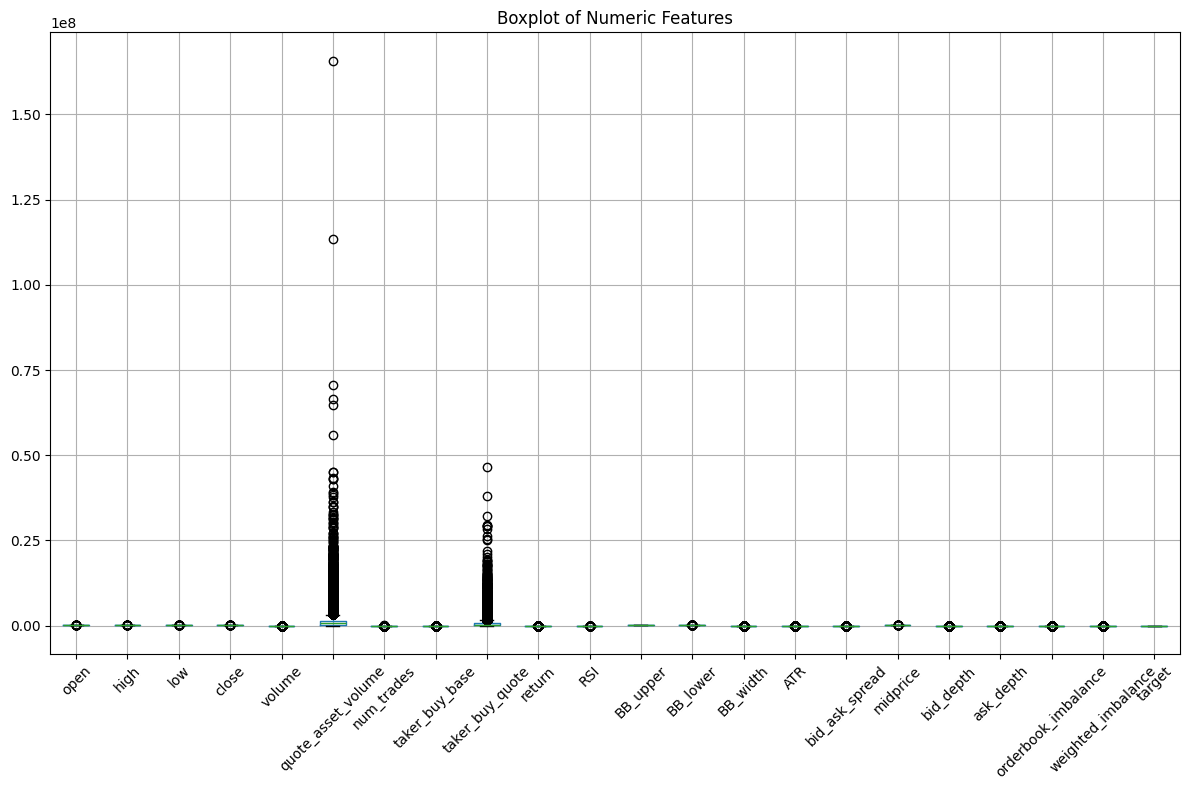

In [23]:
print("Shape:", data_combined.shape)
print("\nColumns:")
print(data_combined.columns)

print("\nHead:")
print(data_combined.head())
print("\nTail:")
print(data_combined.tail())
print("\nMissing values per column:")
print(data_combined.isna().sum())

print("\nNumeric summary:")
print(data_combined.describe())

# Change Categorical data to numeric
obj_cols = ["quote_asset_volume", "taker_buy_base", "taker_buy_quote", "ignore"]
data_combined[obj_cols] = data_combined[obj_cols].apply(pd.to_numeric, errors="coerce")
numeric_cols = data_combined.select_dtypes(include=[np.number]).columns.tolist()

#drop duplicate and stationary features
data_combined = data_combined.drop(['close_time', 'ignore'], axis=1)
numeric_cols.remove('quote_asset_volume')

numeric_cols.remove('taker_buy_quote')

print("\nInfo:")
print(data_combined.info())
plt.figure(figsize=(12, 8))
data_combined.boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Apply Log Transform
Apply log1p transformation to tail-heavy volume and flow features for distribution normalization.

In [24]:
cols = [c for c in data_combined.columns if c != "target"]
q = data_combined[cols].quantile([0.5, 0.99])
tail = (q.loc[0.99] / q.loc[0.5].replace(0, np.nan)).sort_values(ascending=False)
print(tail.head(10))


taker_buy_base        18.754628
taker_buy_quote       18.471707
volume                15.167973
quote_asset_volume    15.142130
num_trades             5.480477
BB_width               4.976159
ATR                    3.849572
bid_ask_spread         2.349574
ask_depth              2.317089
bid_depth              2.216509
dtype: float64


Using specifically Log1p here.
What is does: log1p(x) = log(1 + x).

- For small values, it behaves almost linear: log1p(x) ≈ x
- For large values, it compresses hard: going from 10 → 1000 becomes a much smaller jump than in raw space

So it turns “rare huge spikes” into “moderate bumps,” which makes patterns easier for models to learn.
It’s also safe for zeros (unlike plain log(x)), which is why log1p is standard for volumes/flows/counts.

In [25]:
log_cols = ["taker_buy_base", "taker_buy_quote", "volume", "quote_asset_volume", "num_trades"]
for c in log_cols:
    data_combined[c] = np.log1p(data_combined[c].clip(lower=0))

### Normalize Volatility Metrics
Convert Bollinger Band width and ATR to percentage of price for price-scale independence.

In [26]:
data_combined["ATR_pct"] = data_combined["ATR"] / data_combined["close"]
data_combined["BB_width_pct"] = data_combined["BB_width"] / data_combined["close"]

### Normalize Bid-Ask Spread
Convert spread to basis points (bps) normalized by midprice for scale independence.

In [27]:
data_combined["spread_bps"] = data_combined["bid_ask_spread"].abs() / data_combined["midprice"] * 1e4

### Compute Order Book Depth Metrics
Calculate total depth and depth imbalance as relative measures of liquidity and flow imbalance.

In [28]:
data_combined["depth_sum"] = data_combined["bid_depth"] + data_combined["ask_depth"] # Total depth on both sides of the order book
data_combined["depth_imb"] = (data_combined["bid_depth"] - data_combined["ask_depth"]) / (data_combined["depth_sum"] + 1e-12) # Depth imbalance

### Verify Feature Engineering
Confirm all raw features have been converted and visualize final feature distributions.

In [30]:
data_combined = data_combined.drop(
    columns=["ATR", "BB_width", "BB_upper", "BB_lower", "bid_ask_spread",
             "midprice", "bid_depth", "ask_depth", "open", "high", "low", "close", "ignore"],
    errors='ignore'
)

Print a boxplot of the current data again.


Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 40302 entries, 2025-11-17 00:19:00 to 2025-12-15 00:00:00
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   volume               40302 non-null  float64
 1   quote_asset_volume   40302 non-null  float64
 2   num_trades           40302 non-null  float64
 3   taker_buy_base       40302 non-null  float64
 4   taker_buy_quote      40302 non-null  float64
 5   return               40302 non-null  float64
 6   RSI                  40302 non-null  float64
 7   orderbook_imbalance  40302 non-null  float64
 8   weighted_imbalance   40302 non-null  float64
 9   target               40302 non-null  int64  
 10  ATR_pct              40302 non-null  float64
 11  BB_width_pct         40302 non-null  float64
 12  spread_bps           40302 non-null  float64
 13  depth_sum            40302 non-null  float64
 14  depth_imb            40302 non-null  float64

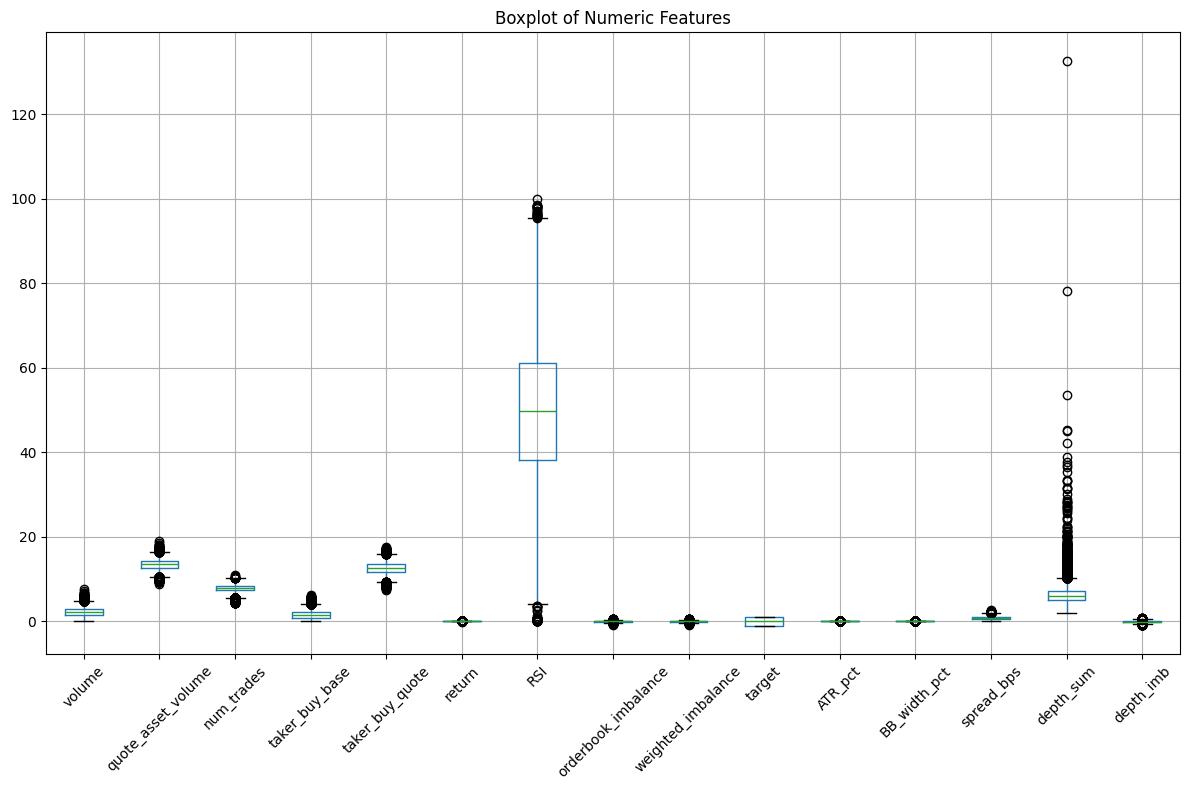

In [31]:
# data_combined = data_combined.drop(columns=["BB_upper", "BB_lower"], errors="ignore")
# data_combined = data_combined.drop(columns=["ignore"], errors="ignore")

print("\nInfo:")
print(data_combined.info())
plt.figure(figsize=(12, 8))
data_combined.boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Combined Hyperparameter Tuning
Grid search for optimal XGBoost hyperparameters using combined features with balanced accuracy scoring.

In [32]:
X_combined = data_combined.drop(columns=['target'])
y_raw_combined = data_combined['target']
y_combined = y_raw_combined.map({-1: 0, 0: 1, 1: 2}).astype(int)  # Map -1 to 0, 0 to 1, and 1 to 2 for multiclass classification

gap = 5  # minutes
n = len(X_combined)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

X_train_combined, y_train_combined = X_combined.iloc[:train_end], y_combined.iloc[:train_end]
X_val_combined, y_val_combined   = X_combined.iloc[train_end+gap:val_end], y_combined.iloc[train_end+gap:val_end]
X_test_combined, y_test_combined  = X_combined.iloc[val_end+gap:], y_combined.iloc[val_end+gap:]

class_counts = y_train_combined.value_counts().sort_index()
class_weights = (class_counts.sum() / class_counts).to_dict()
w_train_combined = y_train_combined.map(class_weights).astype(float)


# Combine train + val into one "tuning" dataset
# X_tune_combined = np.vstack([X_train_combined.values, X_val_combined.values])
# y_tune_combined = np.concatenate([y_train_combined.values, y_val_combined.values])

X_tune_combined = pd.concat([X_train_combined, X_val_combined])
y_tune_combined = pd.concat([y_train_combined, y_val_combined])

# sample weights for val too (use train-derived weights or recompute on train+val)
class_counts = y_train_combined.value_counts().sort_index()
class_weights = (class_counts.sum() / class_counts).to_dict()
w_val_combined = y_val_combined.map(class_weights).astype(float)
# w_tune_combined = np.concatenate([w_train_combined.values, w_val_combined.values])

w_tune_combined = np.concat([w_train_combined.values, w_val_combined.values])


# tell sklearn: -1 means "always train", 0 means "validation fold"
test_fold = np.r_[np.full(len(X_train_combined), -1), np.zeros(len(X_val_combined))]
ps = PredefinedSplit(test_fold)

base = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    random_state=42,
    n_jobs=-1,
    metric="multi_logloss",
    n_estimators=800,
    verbosity=-1
)

scorer = make_scorer(balanced_accuracy_score)

param_grid = {
    "max_depth": [2, 3, 4],
    "min_child_weight": [5, 10, 20],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "reg_lambda": [1.0, 5.0, 10.0],
    "min_split_gain": [0.0, 0.1, 0.2],
    "learning_rate": [0.02, 0.05],
}

search = RandomizedSearchCV(
    base,
    param_distributions=param_grid,
    n_iter=100,
    scoring=scorer,
    cv=ps,
    n_jobs=1,
    verbose=3,
    refit=True
)

search.fit(X_tune, y_tune, sample_weight=w_tune_candle)

print("Best val score:", search.best_score_)
print("Best params:", search.best_params_)

best = search.best_estimator_
pred = best.predict(X_test_candle)

print("Balanced accuracy:", balanced_accuracy_score(y_test_candle, pred))

# grid = GridSearchCV(
#     base, param_grid=param_grid, scoring=scorer, cv=ps,
#     n_jobs=-1, verbose=2, refit=True
# )

# grid.fit(X_tune_combined, y_tune_combined, sample_weight=w_tune_combined)

# print("Best val score:", grid.best_score_)
# print("Best params:", grid.best_params_)

# best = grid.best_estimator_
# pred = best.predict(X_test_combined)

# print("Balanced accuracy:", balanced_accuracy_score(y_test_combined, pred))

# Best val score: 0.41926018538153165
# Best params: {'subsample': 1.0, 'reg_lambda': 1.0, 'min_split_gain': 0.1, 'min_child_weight': 20, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
# Balanced accuracy: 0.44800289027904694


Fitting 1 folds for each of 100 candidates, totalling 100 fits
[CV 1/1] END colsample_bytree=0.85, learning_rate=0.05, max_depth=3, min_child_weight=10, min_split_gain=0.2, reg_lambda=10.0, subsample=1.0;, score=0.415 total time=  10.7s
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.02, max_depth=3, min_child_weight=5, min_split_gain=0.0, reg_lambda=10.0, subsample=0.7;, score=0.414 total time=   8.6s
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.02, max_depth=4, min_child_weight=20, min_split_gain=0.0, reg_lambda=5.0, subsample=0.7;, score=0.416 total time=   9.8s
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.05, max_depth=3, min_child_weight=10, min_split_gain=0.2, reg_lambda=1.0, subsample=0.7;, score=0.417 total time=   6.2s
[CV 1/1] END colsample_bytree=1.0, learning_rate=0.02, max_depth=3, min_child_weight=5, min_split_gain=0.0, reg_lambda=1.0, subsample=1.0;, score=0.415 total time=   8.6s
[CV 1/1] END colsample_bytree=0.85, learning_rate=0.02, max_depth=2, min_chi

### Train Final Combined Model with Early Stopping
Fit with early stopping on validation mlogloss, select optimal iterations, and refit on train+val data.

In [33]:
parameters = search.best_params_

es = search.best_estimator_

# 1) Fit with early stopping on a smooth metric
# es = lgb.LGBMClassifier(
#     objective="multiclass",
#     num_class=3,
#     n_estimators=5000,
#     metric="multi_logloss",
#     random_state=42,
#     n_jobs=-1,
#     verbosity=-1,
#     **parameters,
# )

es.fit(
    X_train_combined, y_train_combined,
    sample_weight=w_train_combined,
    eval_set=[(X_val_combined, y_val_combined)],
    eval_metric="multi_logloss",
    callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)]
)

# 2) Pick best iteration for *your* metric (weighted decision rule)
T = es.best_iteration_
print("Best boosting round (Combined):", T)

if 'n_estimators' in parameters:
    del parameters['n_estimators']

# Refit final model (no early stopping), using that number of trees
final_combined = lgb.LGBMClassifier(
    objective="multiclass",
    num_class=3,
    n_estimators=T,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    **parameters,
)

# optional: train on train+val now that best_t is chosen
X_trval = np.concatenate([X_train_combined.values, X_val_combined.values], axis=0)
y_trval = np.concatenate([y_train_combined.values, y_val_combined.values], axis=0)

final_combined.fit(X_trval, y_trval)

proba_test = final_combined.predict_proba(X_test_combined)
pred_test = (proba_test).argmax(axis=1)
print("Test balanced acc:", balanced_accuracy_score(y_test_combined, pred_test))

Best boosting round (Combined): 50
Test balanced acc: 0.45364374387991013


### Combined Model Weight Optimization
Grid search for optimal class decision weights on validation set and evaluate on test set.

In [34]:
# ============================================================================
# WEIGHT OPTIMIZATION: Find optimal class weights on validation set
# ============================================================================

def predict_weighted(proba, w):
    """Apply class weights to probabilities and make predictions."""
    proba_weighted = proba * np.array(w)[None, :]
    proba_weighted = proba_weighted / proba_weighted.sum(axis=1, keepdims=True)
    return proba_weighted.argmax(axis=1)

# Grid search for optimal weights on validation data
print("Searching for optimal class weights (down, flat, up)...")
print("This may take a minute...\n")

best_w_combined, best_score_combined = None, -1

for w_down in [1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 2.0, 2.5, 3.0]:
    for w_flat in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
        for w_up in [1, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2, 3, 4]:
            proba_val = final_combined.predict_proba(X_val_combined)
            pred = predict_weighted(proba_val, (w_down, w_flat, w_up))
            s = f1_score(y_val_combined, pred, average="macro")
            if s > best_score_combined:
                best_score_combined, best_w_combined = s, (w_down, w_flat, w_up)

print(f"✓ Combined - Best w (down, flat, up): {best_w_combined}")
print(f"  Validation F1 score: {best_score_combined:.6f}")

# Apply best weights to test set
proba_test_combined = final_combined.predict_proba(X_test_combined)
pred_test_combined_opt = predict_weighted(proba_test_combined, best_w_combined)
test_acc_combined_opt = balanced_accuracy_score(y_test_combined, pred_test_combined_opt)
print(f"  Test balanced accuracy (optimized): {test_acc_combined_opt:.6f}\n")

Searching for optimal class weights (down, flat, up)...
This may take a minute...

✓ Combined - Best w (down, flat, up): (1.1, 0.8, 1.1)
  Validation F1 score: 0.439461
  Test balanced accuracy (optimized): 0.473979



### Combined Model Evaluation
Confusion matrix, classification report, and class balance analysis for combined model.

In [35]:
print(confusion_matrix(y_test_combined, pred_test_combined_opt))
print(classification_report(y_test_combined, pred_test_combined_opt, digits=4, target_names=["down","flat","up"]))
print("training period", pd.Series(y_train_combined.value_counts(normalize=True).sort_index()))
print("test period", pd.Series(y_test_combined.value_counts(normalize=True).sort_index()))
print("validation period", pd.Series(y_val_combined.value_counts(normalize=True).sort_index()))

[[ 393  551  631]
 [ 304 2151  458]
 [ 374  505  674]]
              precision    recall  f1-score   support

        down     0.3669    0.2495    0.2971      1575
        flat     0.6707    0.7384    0.7029      2913
          up     0.3823    0.4340    0.4065      1553

    accuracy                         0.5327      6041
   macro avg     0.4733    0.4740    0.4688      6041
weighted avg     0.5174    0.5327    0.5209      6041

training period target
0    0.342526
1    0.312750
2    0.344724
Name: proportion, dtype: float64
test period target
0    0.260718
1    0.482205
2    0.257077
Name: proportion, dtype: float64
validation period target
0    0.314404
1    0.362252
2    0.323344
Name: proportion, dtype: float64


### Visualize Combined Early Stopping Curve
Plot validation mlogloss across boosting rounds with early stopping iteration marked.

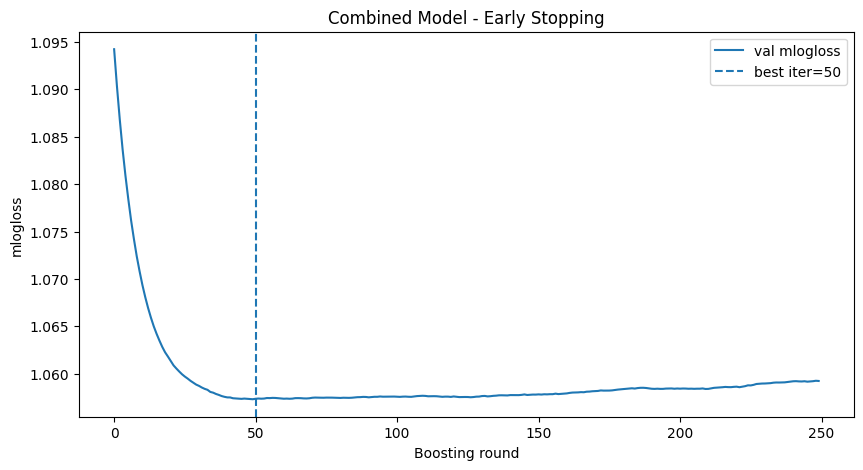

In [36]:
results = es.evals_result_
val_acc = np.array(results['valid_0']['multi_logloss'])
best_it = es.best_iteration_

plt.figure(figsize=(10, 5))
plt.plot(val_acc, label="val mlogloss")
plt.axvline(best_it, linestyle="--", label=f"best iter={best_it}")
plt.xlabel("Boosting round")
plt.ylabel("mlogloss")
plt.title("Combined Model - Early Stopping")
plt.legend()
plt.show()

## Final Model Comparison Summary

In [37]:
# ============================================================================
# MODEL COMPARISON SUMMARY
# ============================================================================

# Collect all model results using calculated values from weight optimization
models_summary = pd.DataFrame({
    'Model': ['Candle', 'Orderbook', 'Combined', 'Ensemble (Candle+Orderbook)'],
    'Features': ['OHLCV', 'Orderbook Microstructure', 'Combined (OHLCV + Orderbook)', 'Alpha blend (Candle+Orderbook)'],
    'Best Iteration': [
        final_candle.n_estimators,
        final_orderbook.n_estimators,
        final_combined.n_estimators,
        np.nan
    ],
    'Test Balanced Accuracy': [
        test_acc_candle_opt,
        test_acc_orderbook_opt,
        test_acc_combined_opt,
        test_score,
    ],
    'Optimal Decision Weights (D, F, U)': [
        str(best_w_candle),
        str(best_w_orderbook),
        str(best_w_combined),
        f"alpha={best_alpha:.3f} | w_c={best_w_candle} | w_o={best_w_orderbook}",
    ]
})

# Display summary
print("\n" + "="*100)
print("MODEL COMPARISON SUMMARY".center(100))
print("="*100)
print(models_summary.to_string(index=False))
print("="*100)

# Key insights
print("\n📊 KEY INSIGHTS:")
print(f"  • Best performing model: {models_summary.loc[models_summary['Test Balanced Accuracy'].idxmax(), 'Model']}")
print(f"    Test Balanced Accuracy: {models_summary['Test Balanced Accuracy'].max():.4f}")
print(f"\n  • Candle model: Quick OHLCV-based predictions")
print(f"  • Orderbook model: Market microstructure signals")
print(f"  • Combined model: Integrated multi-source features")
print("\n" + "="*100)



                                      MODEL COMPARISON SUMMARY                                      
                      Model                       Features  Best Iteration  Test Balanced Accuracy                      Optimal Decision Weights (D, F, U)
                     Candle                          OHLCV            71.0                0.473503                                         (1.2, 0.9, 1.2)
                  Orderbook       Orderbook Microstructure           103.0                0.449410                                         (1.3, 1.0, 1.3)
                   Combined   Combined (OHLCV + Orderbook)            50.0                0.473979                                         (1.1, 0.8, 1.1)
Ensemble (Candle+Orderbook) Alpha blend (Candle+Orderbook)             NaN                0.473012 alpha=0.500 | w_c=(1.2, 0.9, 1.2) | w_o=(1.3, 1.0, 1.3)

📊 KEY INSIGHTS:
  • Best performing model: Combined
    Test Balanced Accuracy: 0.4740

  • Candle model: Quick OHLCV-base